In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [2]:
class PolynomialFeatures:
  def __init__(self) -> None:
    pass

  def transform(self, X, deg):
    exponents = []
    n = len(X.columns)

    for d in range(deg+1):
      results = [p for p in itertools.product(range(d+1), repeat=n) if sum(p) == d]
      for s in results:
        exponents.append(s)

    new_X = pd.DataFrame(index=X.index)

    for exp in exponents:
      col_name = " * ".join([f"{col}^{p}" for col, p in zip(X.columns, exp)])
      val = 1
      for col, p in zip(X.columns, exp):
        val *= X[col] ** p
      new_X[col_name] = val

    return new_X

In [3]:
x = np.linspace(1,50,50)
y = x ** 2 + np.random.uniform(-5,5, 50)
df = pd.DataFrame({
    "x":x,
    "y":y
})
df.head()

,x,y
0,1.0,0.363564
1,2.0,1.365490
2,3.0,5.642906
3,4.0,19.826455
4,5.0,21.424693


Text(0, 0.5, 'y')

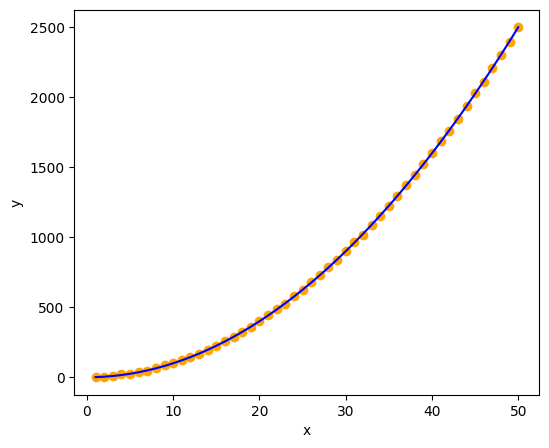

In [4]:
plt.figure(figsize=(6,5))
plt.scatter(df["x"], df["y"], c="orange")
plt.plot(x,x**2,c="blue")
plt.xlabel("x")
plt.ylabel("y")

In [5]:
X = df.drop(columns="y")
Y = df["y"]

In [6]:
polymaker = PolynomialFeatures()
newX = polymaker.transform(X, deg=2)
newX.head()

,x^0,x^1,x^2
0,1.0,1.0,1.0
1,1.0,2.0,4.0
2,1.0,3.0,9.0
3,1.0,4.0,16.0
4,1.0,5.0,25.0


In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
model = LinearRegression(fit_intercept=False)
model.fit(newX, Y)

LinearRegression(fit_intercept=False)

In [9]:
feature_weights = pd.DataFrame(
    {"Feature": newX.columns, "Weight": model.coef_}
).sort_values(by="Weight", key=abs, ascending=False)

print(feature_weights)
print(f"\nModel Intercept: {model.intercept_:.4f}")

  Feature    Weight
2     x^2  0.998770
1     x^1  0.032147
0     x^0 -0.024322

Model Intercept: 0.0000


In [10]:
preds = model.predict(newX)
preds[:5]

array([ 1.0065941 ,  4.03505007,  9.06104548, 16.08458033, 25.10565462])

Text(0, 0.5, 'y')

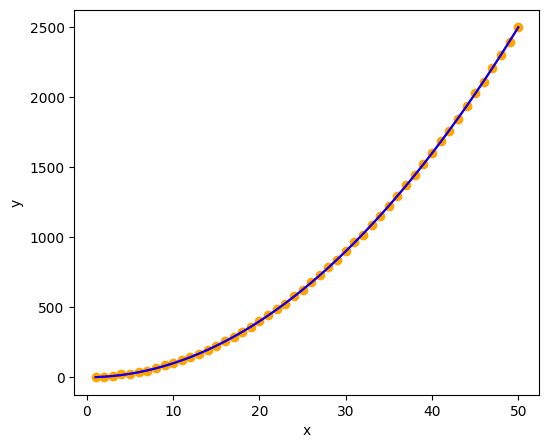

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(df["x"], df["y"], c="orange")
plt.plot(x,preds,c="red")
plt.plot(x,x**2,c="blue")
plt.xlabel("x")
plt.ylabel("y")